# Labor Market microdata Figures



## Active vs Uniform vs Random


Saved figure to /home/nvth2/active_wasserstein_cr/figures/cps_labor_market.pdf


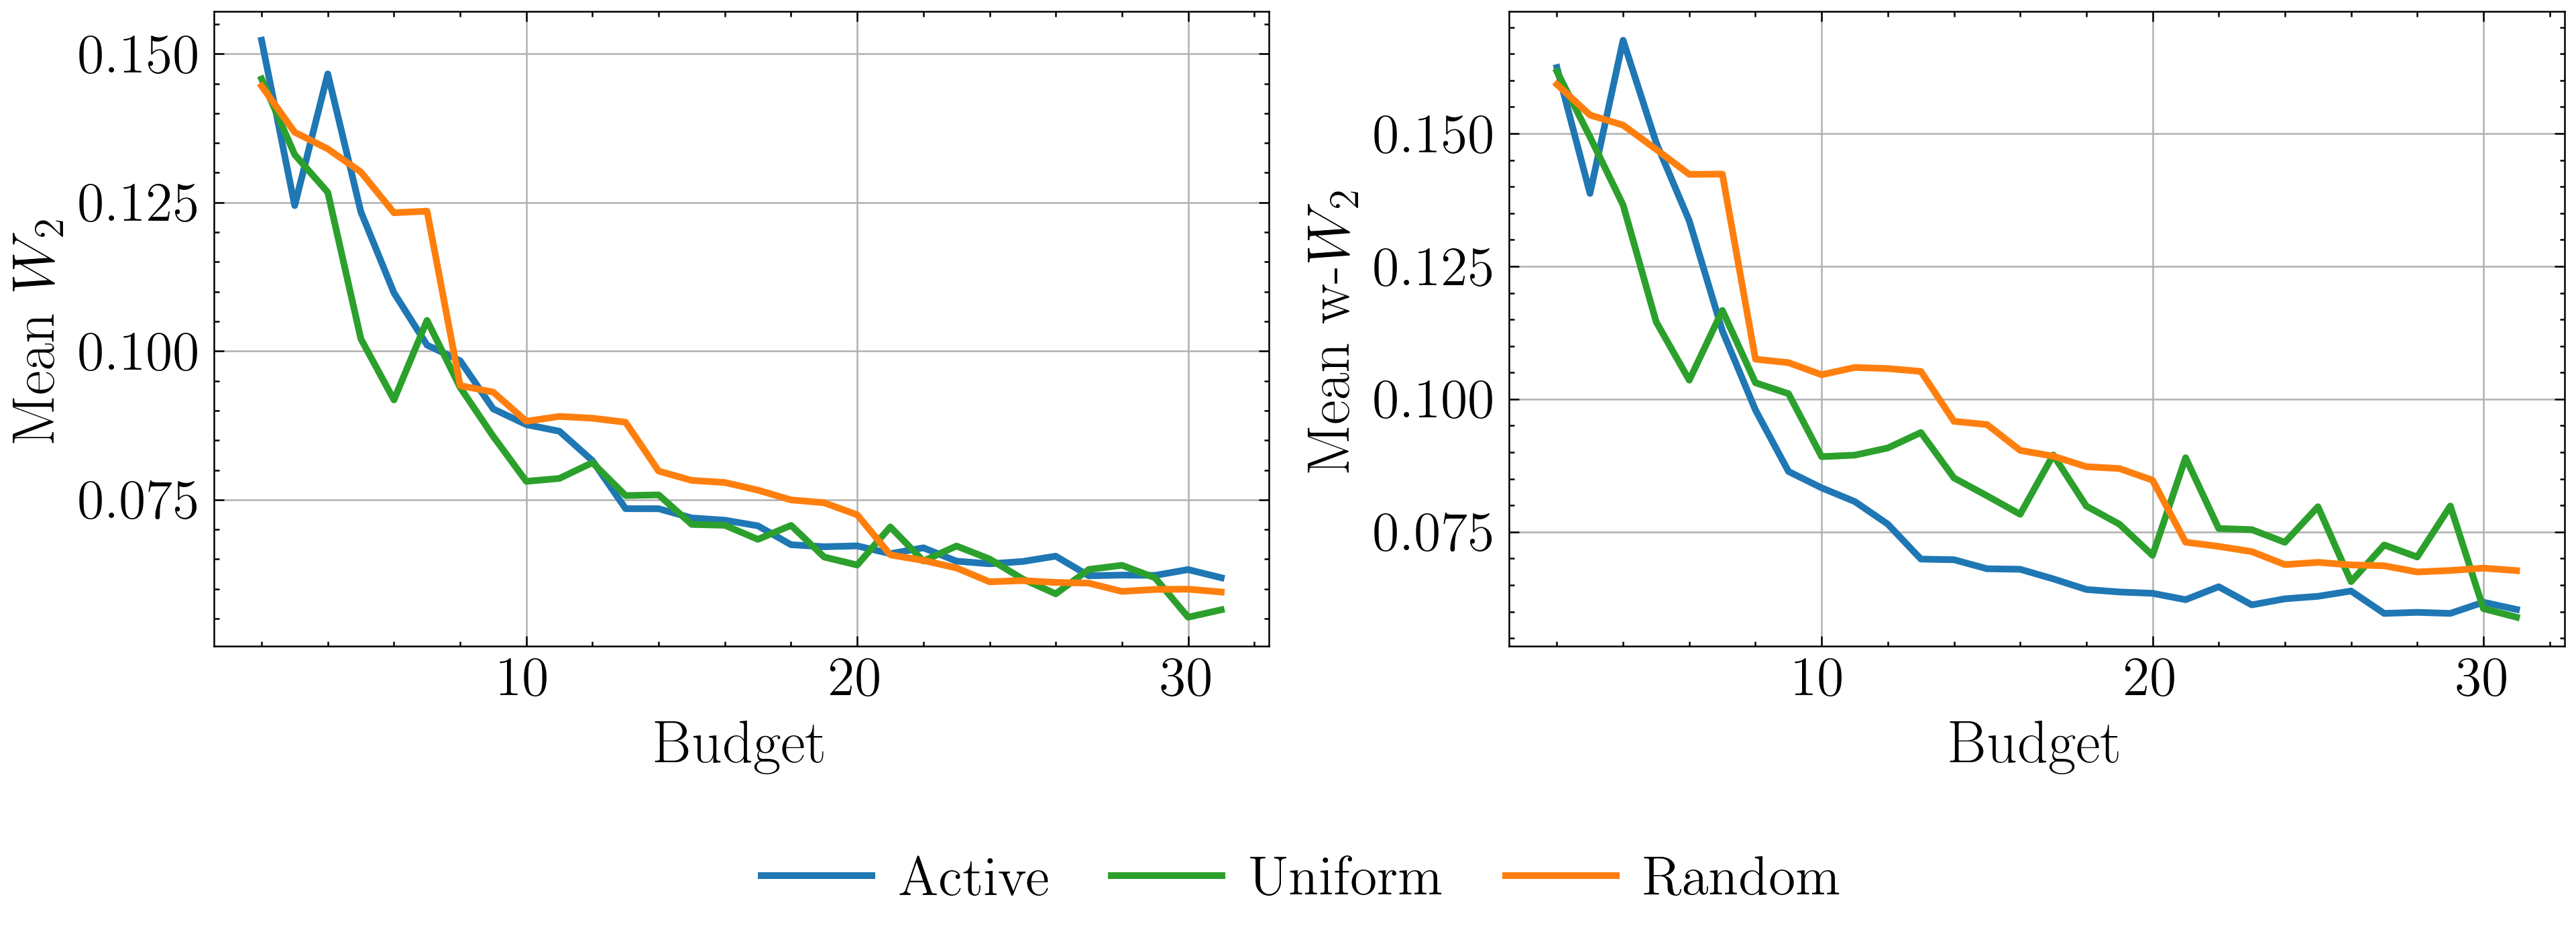

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

try:
    import scienceplots  # noqa: F401
    _HAS_SCIENCEPLOTS = True
except Exception:
    _HAS_SCIENCEPLOTS = False

plt.rcParams['figure.dpi'] = 180
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['axes.grid'] = True
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('retina')
except Exception:
    pass
try:
    import seaborn as sns
    sns.set_context('talk')
except Exception:
    pass

if _HAS_SCIENCEPLOTS:
    plt.style.use(['science'])

MAX_STEP = 30


def _find_repo_root() -> Path:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists():
            return candidate
    return start


REPO_ROOT = _find_repo_root()
RESULTS_ROOT = REPO_ROOT / 'results'
FIG_OUT_DIR = REPO_ROOT / 'figures'

RUN_DIRS = {
    'Active': RESULTS_ROOT / 'cps_labor_market_2026-05-26_00-51-46_active_w2_matern5_2_variance' / '2026-05-26' / '00-51-46',
    'Uniform': RESULTS_ROOT / 'cps_labor_market_2026-05-26_00-51-46_uniform_w2_matern5_2' / '2026-05-26' / '00-51-46',
    'Random': RESULTS_ROOT / 'cps_labor_market_2026-05-26_00-51-46_random_w2_matern5_2' / '2026-05-26' / '00-51-46',
}


def _load_step_metrics(label: str, run_dir: Path) -> pd.DataFrame:
    df = pd.read_csv(run_dir / 'metrics_by_step.csv')
    grouped = df.groupby('step', as_index=False).agg(
        w2=('uniform_metric', 'mean'),
        weighted_w2=('velocity_metric', 'mean'),
    )
    grouped['label'] = label
    return grouped


def _summary_mean(frame: pd.DataFrame, metric: str) -> pd.DataFrame:
    mean = frame.groupby(['label', 'step'])[metric].mean().rename('mean')
    out = mean.reset_index()
    return out.sort_values(['label', 'step'])


all_df = pd.concat(
    [_load_step_metrics(label, run_dir) for label, run_dir in RUN_DIRS.items()],
    ignore_index=True,
)
all_df = all_df[all_df['step'] <= MAX_STEP].copy()

left = _summary_mean(all_df, 'w2')
right = _summary_mean(all_df, 'weighted_w2')

colors = {
    'Active': '#1f77b4',
    'Uniform': '#2ca02c',
    'Random': '#ff7f0e',
}
labels = [x for x in ['Active', 'Uniform', 'Random'] if x in set(all_df['label'])]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True)

for label in labels:
    sub_l = left[left['label'].eq(label)]
    sub_r = right[right['label'].eq(label)]
    c = colors.get(label)

    x_left = sub_l['step'] + 1
    x_right = sub_r['step'] + 1
    axes[0].plot(x_left, sub_l['mean'], color=c, linewidth=2, label=label)

    axes[1].plot(x_right, sub_r['mean'], color=c, linewidth=2, label=label)


for ax in axes:
    ax.set_xlabel('Budget')
    

axes[0].set_ylabel('Mean $W_2$')
axes[1].set_ylabel('Mean w-$W_2$')

legend_handles = [
    Line2D([], [], color=colors[label], linewidth=2, label=label)
    for label in labels
]
fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.005),
    ncol=max(1, len(labels)),
    frameon=False,
    columnspacing=1.1,
    handletextpad=0.5,
)
plt.tight_layout(rect=[0, 0.12, 1, 1])

FIG_OUT_DIR.mkdir(parents=True, exist_ok=True)
fig_out = FIG_OUT_DIR / 'cps_labor_market.pdf'
fig.savefig(fig_out, bbox_inches='tight', dpi=600)
print(f'Saved figure to {fig_out}')
plt.show()


## Acquisition Visualization


Saved to /home/nvth2/active_wasserstein_cr/figures/cps_viz_acquisitions.pdf


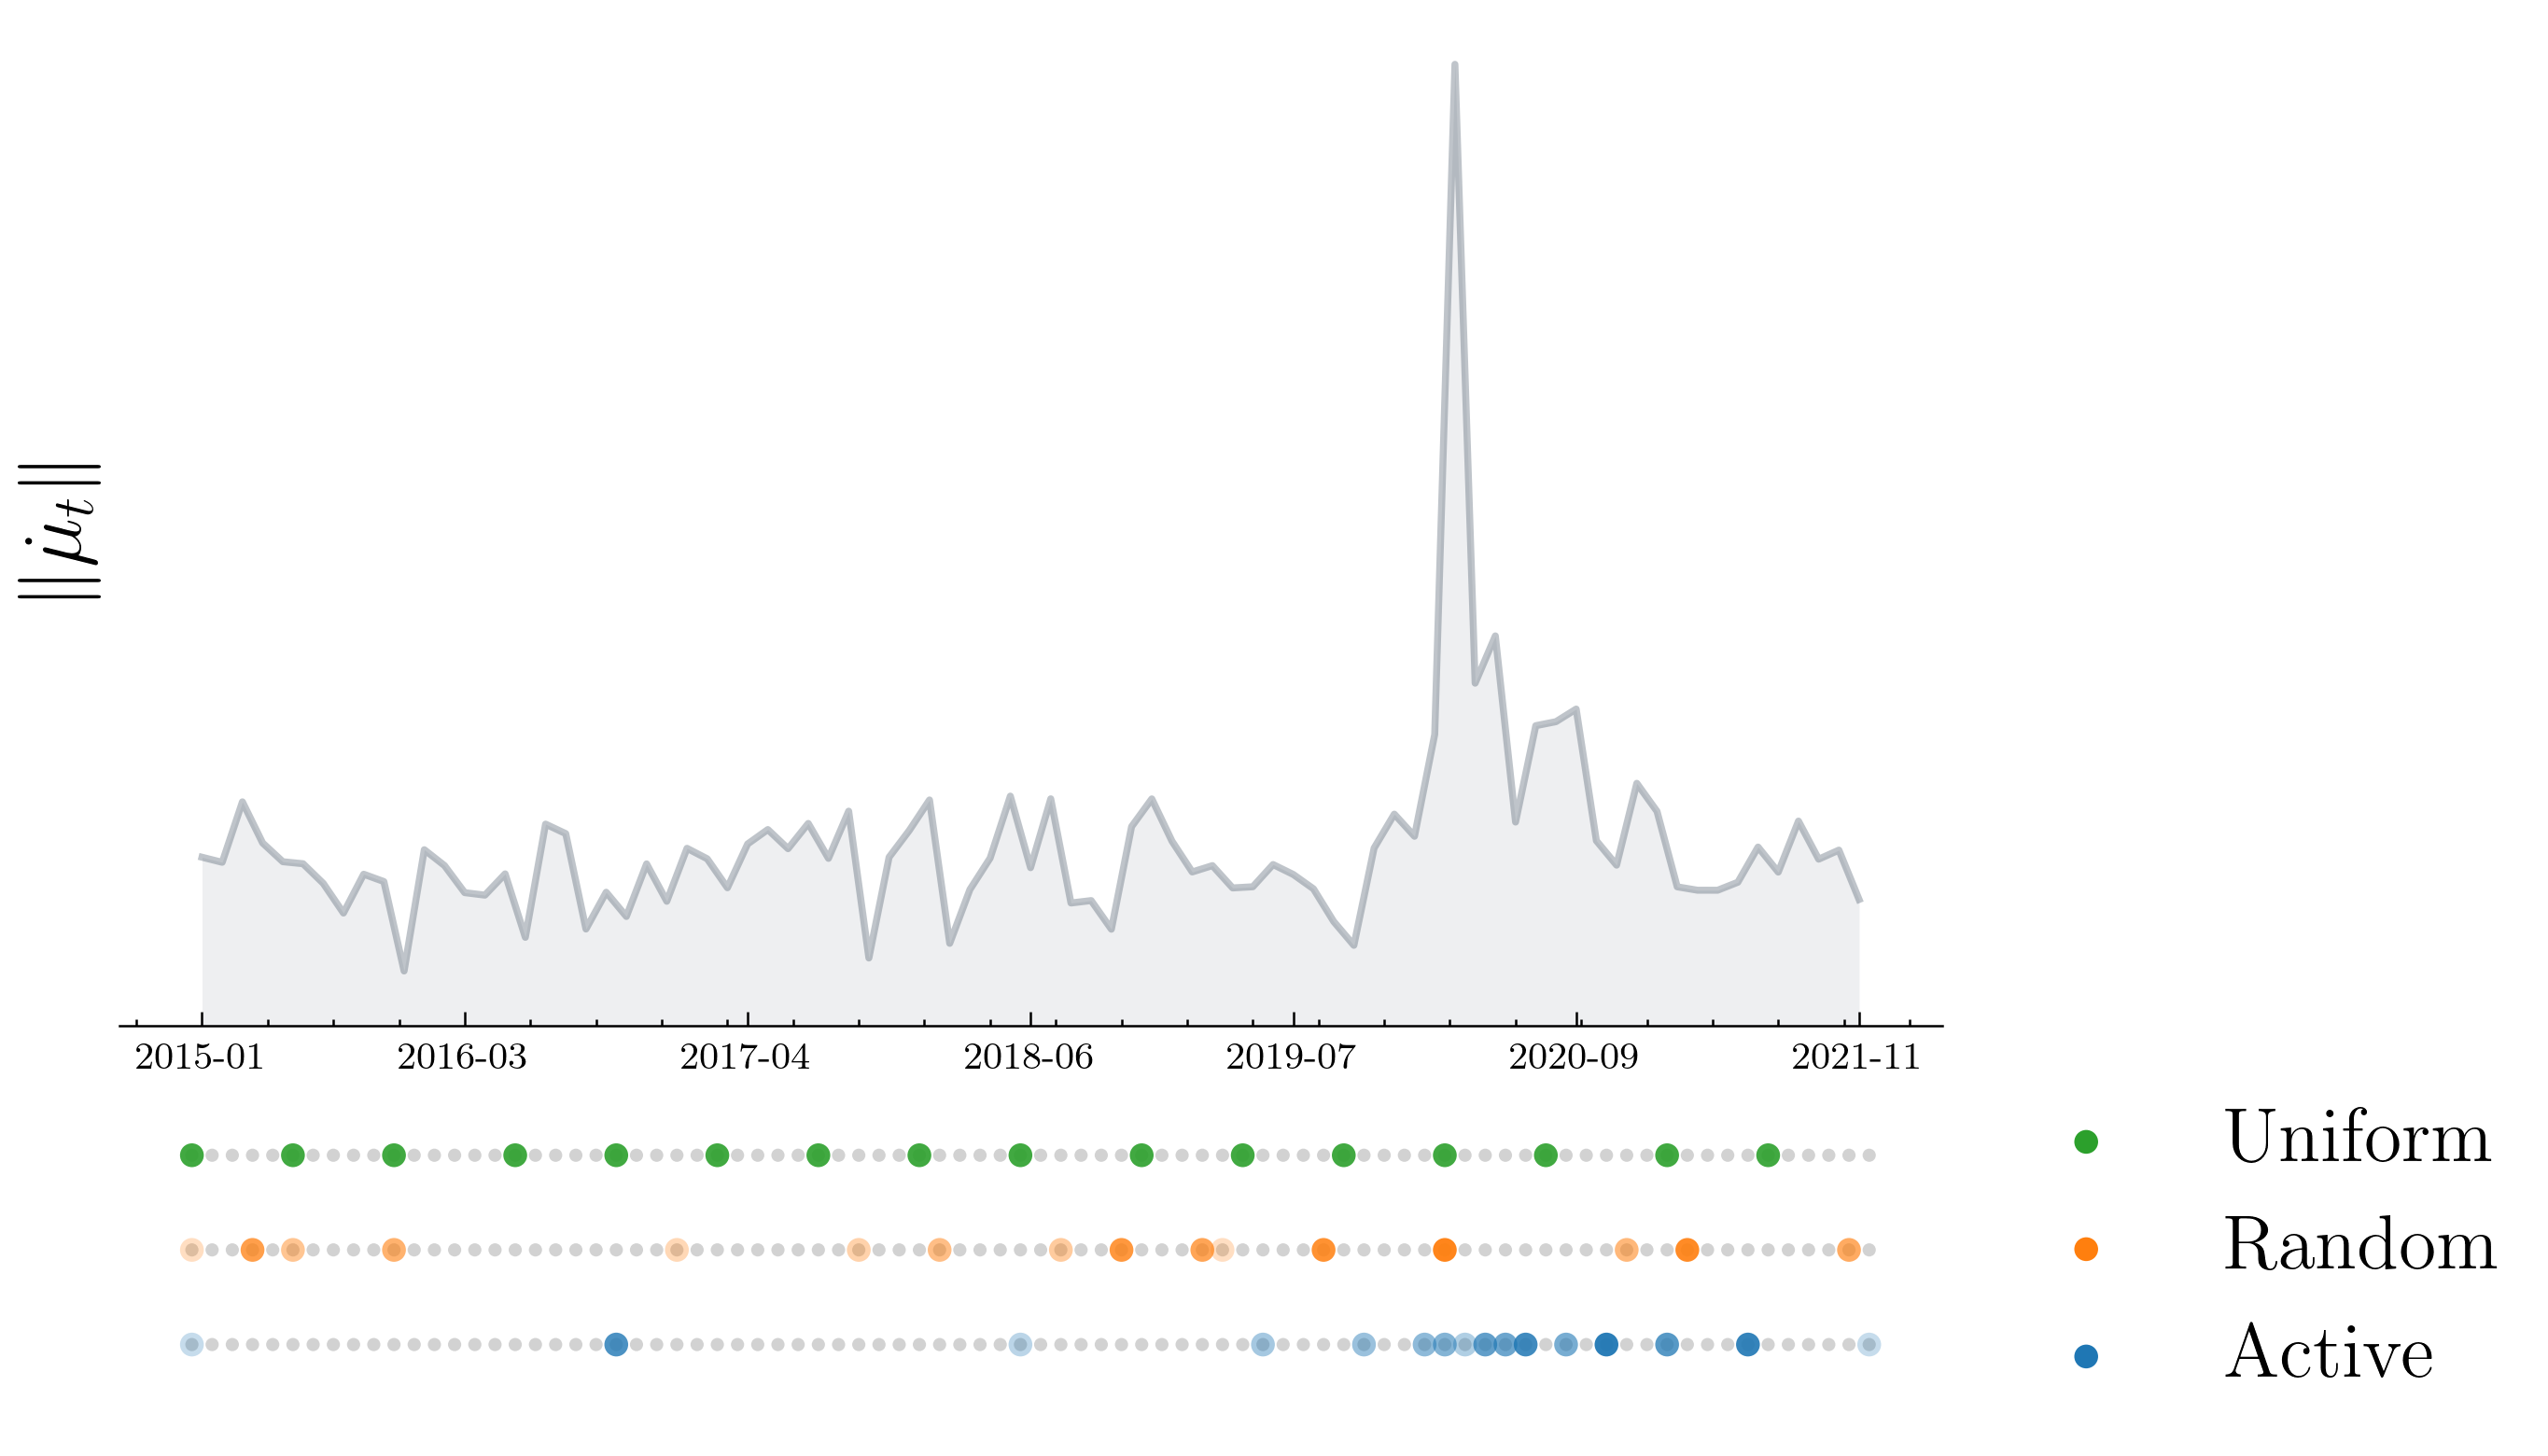

In [2]:
CHECKPOINT = 15
FIG_NAME = 'cps_viz_acquisitions.pdf'

import warnings
warnings.filterwarnings('ignore', message='IProgress not found.*')
warnings.filterwarnings('ignore', message='This figure includes Axes that are not compatible with tight_layout.*')

import json
import pickle
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import colors as mcolors

if 'REPO_ROOT' not in globals() or 'RUN_DIRS' not in globals():
    def _find_repo_root() -> Path:
        start = Path.cwd().resolve()
        for candidate in (start, *start.parents):
            if (candidate / 'pyproject.toml').exists():
                return candidate
        return start

    REPO_ROOT = _find_repo_root()
    RESULTS_ROOT = REPO_ROOT / 'results'
    RUN_DIRS = {
        'Active': RESULTS_ROOT / 'cps_labor_market_2026-05-26_00-51-46_active_w2_matern5_2_variance' / '2026-05-26' / '00-51-46',
        'Uniform': RESULTS_ROOT / 'cps_labor_market_2026-05-26_00-51-46_uniform_w2_matern5_2' / '2026-05-26' / '00-51-46',
        'Random': RESULTS_ROOT / 'cps_labor_market_2026-05-26_00-51-46_random_w2_matern5_2' / '2026-05-26' / '00-51-46',
    }


def load_checkpoint_observed_times(run_dir: Path, strategy: str, step: int) -> np.ndarray | None:
    strategy_dir_name = strategy.replace('/', '_')
    pkl_path = run_dir / 'checkpoint_state' / strategy_dir_name / f'step_{step:03d}.pkl'
    if not pkl_path.exists():
        return None
    try:
        with open(pkl_path, 'rb') as f:
            data = pickle.load(f)
        obs_times = data.get('observed_times')
        return np.asarray(obs_times) if obs_times is not None else None
    except Exception as e:
        if 'No module named' in str(e):
            return None
        raise


def checkpoint_times_from_artifacts(payload: dict, checkpoint: int | None) -> np.ndarray | None:
    obs_all = payload.get('observed_times')
    history = payload.get('acquisition_history') or []

    if checkpoint is None:
        if obs_all is not None:
            return np.asarray(obs_all, dtype=float)
        vals = [float(r['selected_time']) for r in history if 'selected_time' in r]
        return np.asarray(vals, dtype=float) if vals else None

    selected = []
    if history:
        hist_df = pd.DataFrame(history)
        if not hist_df.empty:
            step_field = next((c for c in ('step', 'iteration', 'checkpoint', 'checkpoint_idx') if c in hist_df.columns), None)
            if step_field is not None:
                selected = hist_df[hist_df[step_field] < checkpoint]['selected_time'].tolist()
            elif 'selected_time' in hist_df.columns:
                selected = hist_df['selected_time'].tolist()[:checkpoint]

    out = []
    if obs_all is not None:
        obs_arr = np.asarray(obs_all, dtype=float)
        if obs_arr.size:
            out.append(float(obs_arr[0]))
    out.extend(float(x) for x in selected)
    return np.asarray(list(dict.fromkeys(out)), dtype=float) if out else None


def _month_labels_from_metadata(run_dir: Path, eval_times: np.ndarray) -> np.ndarray | None:
    meta_path = run_dir / 'metadata.json'
    if not meta_path.exists():
        return None
    try:
        meta = json.loads(meta_path.read_text())
        traj_path = meta.get('trajectory', {}).get('path')
        if not traj_path:
            return None

        npz = np.load(traj_path, allow_pickle=True)
        month_labels = npz.get('month_labels', None)
        traj_eval_times = npz.get('eval_times', None)
        if month_labels is None or traj_eval_times is None:
            return None

        month_labels = np.asarray(month_labels).astype(str)
        traj_eval_times = np.asarray(traj_eval_times, dtype=float)
        eval_times = np.asarray(eval_times, dtype=float)
        if month_labels.size != traj_eval_times.size or eval_times.size == 0:
            return None

        idx = [int(np.argmin(np.abs(traj_eval_times - t))) for t in eval_times]

        def _to_year_month(label: str) -> str:
            m = re.match(r'^(\d{4})-(\d{2})', str(label))
            return f'{m.group(1)}-{m.group(2)}' if m else str(label)

        return np.asarray([_to_year_month(month_labels[i]) for i in idx], dtype=str)
    except Exception:
        return None


def _apply_date_ticks(ax, x_vals: np.ndarray, month_labels: np.ndarray | None, eval_times: np.ndarray | None, max_ticks: int = 7) -> bool:
    if month_labels is None:
        return False

    x_vals = np.asarray(x_vals, dtype=float)
    month_labels = np.asarray(month_labels).astype(str)
    if x_vals.size == 0 or month_labels.size == 0:
        return False

    if month_labels.size == x_vals.size:
        labels_for_x = month_labels
    else:
        if eval_times is None:
            return False
        eval_times = np.asarray(eval_times, dtype=float)
        if eval_times.size != month_labels.size:
            return False
        idx = np.array([int(np.argmin(np.abs(eval_times - xv))) for xv in x_vals], dtype=int)
        labels_for_x = month_labels[idx]

    n_ticks = min(max_ticks, x_vals.size)
    tick_idx = np.unique(np.linspace(0, x_vals.size - 1, n_ticks, dtype=int))
    ax.set_xticks(x_vals[tick_idx])
    ax.set_xticklabels(labels_for_x[tick_idx], rotation=0, fontsize=8)
    return True


def _alpha_from_steps(steps: np.ndarray | None) -> np.ndarray | None:
    if steps is None:
        return None
    steps = np.asarray(steps, dtype=float)
    if steps.size == 0:
        return None
    valid = np.isfinite(steps)
    if not np.any(valid):
        return None
    alpha_min = 0.25
    alpha_max = 0.95
    s_min = steps[valid].min()
    s_max = steps[valid].max()
    if s_max == s_min:
        out = np.full_like(steps, alpha_max, dtype=float)
    else:
        norm = (steps - s_min) / (s_max - s_min)
        out = alpha_min + norm * (alpha_max - alpha_min)
    out[~valid] = alpha_min
    return out


label_order = ['Uniform', 'Random', 'Active']
acquisition = {}
strategies = {}
candidate_pool = None
eval_times = None
eval_velocities = None
month_tick_labels = None

for label in label_order:
    run_dir = RUN_DIRS[label]
    art = json.loads((run_dir / 'acquisition_artifacts.json').read_text())
    strategy, payload = next(iter(art.items()))
    acquisition[label] = payload
    strategies[label] = strategy

    if candidate_pool is None:
        candidate_pool = np.asarray(np.load(run_dir / 'shared_artifacts' / 'candidate_pool.npy'), dtype=float)
    if eval_times is None:
        eval_times = np.asarray(np.load(run_dir / 'shared_artifacts' / 'eval_times.npy'), dtype=float)
    if eval_velocities is None:
        eval_velocities = np.asarray(np.load(run_dir / 'shared_artifacts' / 'eval_velocities.npy'), dtype=float)
    if month_tick_labels is None:
        month_tick_labels = _month_labels_from_metadata(run_dir, eval_times)

row_spacing = 0.2
n_strategies = len(label_order)
y_map = {
    label: (n_strategies - 1 - i) * row_spacing
    for i, label in enumerate(label_order)
}
strip_ratio = max(0.6, 0.25 * n_strategies)
fig, (ax_vel, ax_strip) = plt.subplots(
    2,
    1,
    figsize=(7, 5.5),
    gridspec_kw={'height_ratios': [2.0, strip_ratio], 'hspace': 0.05},
)

ax_strip.set_facecolor('none')
ax_strip.patch.set_alpha(0)
ax_strip.set_zorder(0)
ax_vel.set_zorder(1)

if len(eval_velocities) == len(eval_times):
    x = eval_times
elif len(eval_velocities) == len(eval_times) - 1:
    x = 0.5 * (eval_times[:-1] + eval_times[1:])
else:
    x = np.arange(len(eval_velocities), dtype=float)

vel_color = '#2c3e50'
ax_vel.fill_between(x, 0, eval_velocities, alpha=0.08, color=vel_color, linewidth=0)
ax_vel.plot(x, eval_velocities, linewidth=1.5, color=vel_color, alpha=0.3)
ax_vel.set_ylabel(r'$\|\dot{\mu}_t\|$')
used_date_ticks = _apply_date_ticks(
    ax_vel,
    x,
    month_tick_labels,
    eval_times=eval_times,
    max_ticks=7,
)
if used_date_ticks:
    ax_vel.set_xlabel('')
else:
    ax_vel.set_xlabel('$t$', loc='right')
ax_vel.tick_params(axis='x', labelbottom=True, bottom=True, top=False, which='both')
ax_vel.tick_params(axis='y', left=False, right=False, labelleft=False, length=0, which='both')
ax_vel.set_yticks([])
ax_vel.xaxis.set_ticks_position('bottom')
ax_vel.spines['top'].set_visible(False)
ax_vel.spines['right'].set_visible(False)
ax_vel.spines['left'].set_visible(False)
ax_vel.grid(False)
ax_vel.set_ylim(bottom=0)

colors = {'Active': '#1f77b4', 'Random': '#ff7f0e', 'Uniform': '#2ca02c'}
for label in label_order:
    y = y_map[label]
    ax_strip.scatter(
        candidate_pool,
        np.full_like(candidate_pool, y, dtype=float),
        s=8,
        alpha=0.5,
        color='0.65',
        edgecolors='none',
        zorder=1,
    )

labels_used = set()
for label in label_order:
    run_dir = RUN_DIRS[label]
    strategy = strategies[label]
    payload = acquisition[label]

    acquired_times = None
    if CHECKPOINT is not None:
        acquired_times = load_checkpoint_observed_times(run_dir, strategy, int(CHECKPOINT))
    if acquired_times is None:
        acquired_times = checkpoint_times_from_artifacts(payload, CHECKPOINT)
    if acquired_times is None or len(acquired_times) == 0:
        continue

    acquired_steps = None
    history = payload.get('acquisition_history') or []
    if history:
        hist_df = pd.DataFrame(history)
        if not hist_df.empty:
            step_field = next((c for c in ('step', 'iteration', 'checkpoint', 'checkpoint_idx') if c in hist_df.columns), None)
            if step_field is not None and 'selected_time' in hist_df.columns:
                step_map = (
                    hist_df.dropna(subset=['selected_time', step_field])
                    .drop_duplicates('selected_time')
                    .set_index('selected_time')[step_field]
                )
                acquired_steps = np.array(
                    [step_map.get(float(t), np.nan) for t in acquired_times],
                    dtype=float,
                )
                if np.all(np.isnan(acquired_steps)):
                    acquired_steps = None

    y = np.full(len(acquired_times), y_map[label], dtype=float)
    color = colors[label]
    plot_label = label if label not in labels_used else None
    labels_used.add(label)

    if label in {'Active', 'Random'} and acquired_steps is not None:
        alphas = _alpha_from_steps(acquired_steps)
        if alphas is not None:
            rgba = np.tile(mcolors.to_rgba(color), (len(acquired_times), 1))
            rgba[:, 3] = alphas
            ax_strip.scatter(
                acquired_times,
                y,
                s=26,
                color=rgba,
                label=plot_label,
                edgecolors='none',
                zorder=2,
            )
            continue

    ax_strip.scatter(
        acquired_times,
        y,
        s=26,
        alpha=0.9,
        color=color,
        label=plot_label,
        edgecolors='none',
        zorder=2,
    )

max_y = (n_strategies - 1) * row_spacing
ax_strip.set_ylim(-0.2, max_y + 0.2)
ax_strip.set_yticks([])
ax_strip.tick_params(axis='y', left=False)
ax_strip.grid(False)
for spine in ax_strip.spines.values():
    spine.set_visible(False)
ax_strip.tick_params(axis='x', labelbottom=False, bottom=False)
ax_strip.set_xticks([])
ax_strip.set_xlim(ax_vel.get_xlim())

handles, labels = ax_strip.get_legend_handles_labels()
label_to_handle = {lab: h for h, lab in zip(handles, labels) if lab}
ordered_labels = [lab for lab in label_order if lab in label_to_handle]
ordered_handles = [label_to_handle[lab] for lab in ordered_labels]
if ordered_handles:
    leg = ax_strip.legend(
        ordered_handles,
        ordered_labels,
        loc='center left',
        bbox_to_anchor=(1.02, 0.50),
        borderaxespad=0.0,
        ncol=1,
    )
    for lh in leg.legend_handles:
        lh.set_alpha(1.0)
        if hasattr(lh, 'set_facecolors'):
            fc = lh.get_facecolors()
            if len(fc) > 0:
                fc[:, 3] = 1.0
                lh.set_facecolors(fc)

plt.tight_layout()

out_path = REPO_ROOT / 'figures' / FIG_NAME
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, bbox_inches='tight', dpi=300)
print(f'Saved to {out_path}')
plt.show()
